In [4]:
# plotting the results of the benchmark 
import matplotlib.pyplot as plt
import numpy as np
import glob
import pandas as pd
import seaborn as sns
from matplotlib.ticker import LogLocator
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from math import pi

# replicate indices 
replicate_indices = [str(i).zfill(2) for i in range(1, 31)]
res_base_path = "/mnt/ssd/performance_benchmark"


## Dataframe generation 

This extracts the runtime and resource usage for the 30 replicate runs and constructs a data frame saved to csv 

In [2]:
# initiating empty lists to store the values
# --- matlab ---
matlab_intensity_realtime_values = []
matlab_intensity_peak_rss_values = []
matlab_intensity_rchar_values = []
matlab_intensity_wchar_values = []
matlab_intensity_read_bytes_values = []
matlab_intensity_write_bytes_values = []
matlab_intensity_pmem_values = []
matlab_intensity_pcpu_values = []
matlab_intensity_peak_vmem_values = []


matlab_alignment_realtime_values = []
matlab_alignment_peak_rss_values = []
matlab_alignment_rchar_values = []
matlab_alignment_wchar_values = []
matlab_alignment_read_bytes_values = []
matlab_alignment_write_bytes_values = []
matlab_alignment_pmem_values = []
matlab_alignment_pcpu_values = []
matlab_alignment_peak_vmem_values = []

matlab_stitching_realtime_values = []
matlab_stitching_peak_rss_values = []
matlab_stitching_rchar_values = []
matlab_stitching_wchar_values = []
matlab_stitching_read_bytes_values = []
matlab_stitching_write_bytes_values = []
matlab_stitching_pmem_values = []
matlab_stitching_pcpu_values = []
matlab_stitching_peak_vmem_values = []

matlab_count_realtime_values = []
matlab_count_peak_rss_values = []
matlab_count_rchar_values = []
matlab_count_wchar_values = []
matlab_count_read_bytes_values = []
matlab_count_write_bytes_values = []
matlab_count_pmem_values = []
matlab_count_pcpu_values = []
matlab_count_peak_vmem_values = []

# --- nextflow ---
nextflow_intensity_realtime_values = []
nextflow_intensity_peak_rss_values = []
nextflow_intensity_rchar_values = []
nextflow_intensity_wchar_values = []
nextflow_intensity_read_bytes_values = []
nextflow_intensity_write_bytes_values = []
nextflow_intensity_pmem_values = []
nextflow_intensity_pcpu_values = []
nextflow_intensity_peak_vmem_values = []


nextflow_alignment_realtime_values = []
nextflow_alignment_peak_rss_values = []
nextflow_alignment_rchar_values = []
nextflow_alignment_wchar_values = []
nextflow_alignment_read_bytes_values = []
nextflow_alignment_write_bytes_values = []
nextflow_alignment_pmem_values = []
nextflow_alignment_pcpu_values = []
nextflow_alignment_peak_vmem_values = []


nextflow_stitching_realtime_values = []
nextflow_stitching_peak_rss_values = []
nextflow_stitching_rchar_values = []
nextflow_stitching_wchar_values = []
nextflow_stitching_read_bytes_values = []
nextflow_stitching_write_bytes_values = []
nextflow_stitching_pmem_values = []
nextflow_stitching_pcpu_values = []
nextflow_stitching_peak_vmem_values = []

nextflow_count_realtime_values = []
nextflow_count_peak_rss_values = []
nextflow_count_rchar_values = []
nextflow_count_wchar_values = []
nextflow_count_read_bytes_values = []
nextflow_count_write_bytes_values = []
nextflow_count_pmem_values = []
nextflow_count_pcpu_values = []
nextflow_count_peak_vmem_values = []


In [5]:
# aggregate data from matlab/replicate_[index]/process_intensity/ get the matlab_trace.log file and extract the realtime value.

#iterate over the list of strings for the index since they are 0 padded in the folder names
for i in replicate_indices:
    with open(f'{res_base_path}/matlab/replicate_{i}/process_intensity/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_intensity_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_intensity_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_intensity_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_intensity_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_intensity_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_intensity_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_intensity_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_intensity_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_intensity_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_align/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_alignment_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_alignment_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_alignment_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_alignment_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_alignment_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_alignment_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_alignment_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_alignment_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_alignment_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_stitch/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_stitching_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_stitching_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_stitching_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_stitching_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_stitching_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_stitching_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_stitching_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_stitching_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_stitching_peak_vmem_values.append(peak_vmem_value)
    with open(f'{res_base_path}/matlab/replicate_{i}/process_count/matlab_trace.log', 'r') as f:
        for line in f:
            if 'realtime' in line:
                realtime_value = float(line.split('realtime=')[1].strip())
                matlab_count_realtime_values.append(realtime_value)
            if 'peak_rss' in line:
                peak_rss_value = float(line.split('peak_rss=')[1].strip())
                matlab_count_peak_rss_values.append(peak_rss_value)
            if 'rchar' in line:
                rchar_value = float(line.split('rchar=')[1].strip())
                matlab_count_rchar_values.append(rchar_value)
            if 'wchar' in line:
                wchar_value = float(line.split('wchar=')[1].strip())
                matlab_count_wchar_values.append(wchar_value)
            if 'read_bytes' in line:
                read_bytes_value = float(line.split('read_bytes=')[1].strip())
                matlab_count_read_bytes_values.append(read_bytes_value)
            if 'write_bytes' in line:
                write_bytes_value = float(line.split('write_bytes=')[1].strip())
                matlab_count_write_bytes_values.append(write_bytes_value)
            if '%mem' in line:
                mem_value = float(line.split('%mem=')[1].strip())
                matlab_count_pmem_values.append(mem_value)
            if '%cpu' in line:
                cpu_value = float(line.split('%cpu=')[1].strip())
                matlab_count_pcpu_values.append(cpu_value)
            if 'peak_vmem' in line:
                peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                matlab_count_peak_vmem_values.append(peak_vmem_value)

In [8]:
# from the value arrays create a pandas datafram with the following columns: 
# process; realtime; peak_rss; software
# and the values in the process column should be 'intensity', 'alignment', 'stitching', 'count'
# the software column should be 'matlab' for the matlab values and 'nextflow' for the nextflow values

matlab_df = pd.DataFrame({
    'process': ['intensity'] * len(matlab_intensity_realtime_values) +
               ['alignment'] * len(matlab_alignment_realtime_values) +
               ['stitching'] * len(matlab_stitching_realtime_values) +
               ['count'] * len(matlab_count_realtime_values),
    'realtime': matlab_intensity_realtime_values +
                matlab_alignment_realtime_values +
                matlab_stitching_realtime_values +
                matlab_count_realtime_values,
    'peak_rss': matlab_intensity_peak_rss_values +
                matlab_alignment_peak_rss_values +
                matlab_stitching_peak_rss_values +
                matlab_count_peak_rss_values,
    'rchar': matlab_intensity_rchar_values +
             matlab_alignment_rchar_values +
             matlab_stitching_rchar_values +
             matlab_count_rchar_values,
    'wchar': matlab_intensity_wchar_values +
             matlab_alignment_wchar_values +
             matlab_stitching_wchar_values +
             matlab_count_wchar_values,
    'read_bytes': matlab_intensity_read_bytes_values +
                  matlab_alignment_read_bytes_values +
                  matlab_stitching_read_bytes_values +
                  matlab_count_read_bytes_values,
    'write_bytes': matlab_intensity_write_bytes_values +
                   matlab_alignment_write_bytes_values +
                   matlab_stitching_write_bytes_values +
                   matlab_count_write_bytes_values,
    'pmem': matlab_intensity_pmem_values +
            matlab_alignment_pmem_values +
            matlab_stitching_pmem_values +
            matlab_count_pmem_values,
    'pcpu': matlab_intensity_pcpu_values +
            matlab_alignment_pcpu_values +
            matlab_stitching_pcpu_values +
            matlab_count_pcpu_values,
     'peak_vmem': matlab_intensity_peak_vmem_values +
                   matlab_alignment_peak_vmem_values +
                   matlab_stitching_peak_vmem_values +
                   matlab_count_peak_vmem_values,
    'software': ['matlab'] * (len(matlab_intensity_realtime_values) +
                             len(matlab_alignment_realtime_values) +
                             len(matlab_stitching_realtime_values) +
                             len(matlab_count_realtime_values))
})



In [9]:
matlab_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software
0,intensity,33354.0,1631720.0,98386458.0,183114840.0,8192.0,183414784.0,24.0,1823.0,10285120.0,matlab
1,intensity,34158.0,1575072.0,97881185.0,183114839.0,2793472.0,183439360.0,24.0,1842.0,10346680.0,matlab
2,intensity,34273.0,1641972.0,97881146.0,183114840.0,12288.0,183443456.0,24.0,1766.0,10310440.0,matlab
3,intensity,33799.0,1594140.0,98388931.0,183114840.0,12288.0,183414784.0,24.0,1779.0,10268932.0,matlab
4,intensity,32808.0,1589956.0,98387500.0,183114842.0,4096.0,183418880.0,24.0,1859.0,10574732.0,matlab
...,...,...,...,...,...,...,...,...,...,...,...
115,count,151322.0,10901200.0,67374313.0,2190308.0,0.0,2588672.0,165.0,44.0,53579664.0,matlab
116,count,149851.0,10844528.0,65285270.0,2190303.0,0.0,2588672.0,165.0,44.0,54197936.0,matlab
117,count,150889.0,10882504.0,67375853.0,2190301.0,0.0,2596864.0,166.0,44.0,54234840.0,matlab
118,count,150596.0,10852888.0,67374320.0,2190308.0,0.0,2605056.0,165.0,45.0,53643300.0,matlab


In [14]:
# get the data from the work dir -- correct values --- 
# create df with columns: process; hash/id
nextflow_id_df = pd.DataFrame(columns=['replicate','process', 'hash/id'])
# fill the df with the values from the files by iterating over the replicates and processes
for i in replicate_indices:
    file_pattern = f'{res_base_path}/nextflow/replicate_{i}/pipeline_info/execution_trace_*.txt'
    file_list = glob.glob(file_pattern)
    if file_list:
        df = pd.read_csv(file_list[0], sep='\t')
        # Create rows to add
        rows_to_add = [
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)']['hash'].values[0]},
            {'replicate': i, 'process': 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)', 
             'hash/id': df[df['name'] == 'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)']['hash'].values[0]}
        ]
        
        # Use pd.concat to add rows
        nextflow_id_df = pd.concat([nextflow_id_df, pd.DataFrame(rows_to_add)], ignore_index=True)

In [11]:
nextflow_id_df

# adding two new empty columns to the dataframe 
nextflow_id_df['realtime'] = np.nan
nextflow_id_df['peak_rss'] = np.nan
nextflow_id_df['rchar'] = np.nan
nextflow_id_df['wchar'] = np.nan
nextflow_id_df['read_bytes'] = np.nan
nextflow_id_df['write_bytes'] = np.nan
nextflow_id_df['pmem'] = np.nan
nextflow_id_df['pcpu'] = np.nan
nextflow_id_df['peak_vmem'] = np.nan


In [15]:
# now iterating over the  rows in the dataframe, getting into the work dir and from the hash in the dataframe into the right sub dir to finde there the trace file and add real time and peak rss to the dataframe for the specific hash 
for index, row in nextflow_id_df.iterrows():
    replicate = row['replicate']
    process = row['process']
    hash_id = row['hash/id']
    
    # Construct the path to the trace file with glob pattern to find the trace file in the right subdir
    trace_file_pattern = f'{res_base_path}/nextflow/replicate_{replicate}/work/{hash_id}*/.command.trace'
    trace_file_path = glob.glob(trace_file_pattern)
    if trace_file_path:
        with open(trace_file_path[0], 'r') as f:
            for line in f:
                if 'realtime' in line:
                    realtime_value = float(line.split('realtime=')[1].strip())
                    # get the row with the current replicate and add the realtime value to the realtime column
                    nextflow_id_df.at[index, 'realtime'] = realtime_value
                if 'peak_rss' in line:
                    peak_rss_value = float(line.split('peak_rss=')[1].strip())
                    nextflow_id_df.at[index, 'peak_rss'] = peak_rss_value
                if 'rchar' in line:
                    rchar_value = float(line.split('rchar=')[1].strip())
                    nextflow_id_df.at[index, 'rchar'] = rchar_value
                if 'wchar' in line:
                    wchar_value = float(line.split('wchar=')[1].strip())
                    nextflow_id_df.at[index, 'wchar'] = wchar_value
                if 'read_bytes' in line:
                    read_bytes_value = float(line.split('read_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'read_bytes'] = read_bytes_value
                if 'write_bytes' in line:
                    write_bytes_value = float(line.split('write_bytes=')[1].strip())
                    nextflow_id_df.at[index, 'write_bytes'] = write_bytes_value
                if '%mem' in line:
                    mem_value = float(line.split('%mem=')[1].strip())
                    nextflow_id_df.at[index, 'pmem'] = mem_value
                if '%cpu' in line:
                    cpu_value = float(line.split('%cpu=')[1].strip())
                    nextflow_id_df.at[index, 'pcpu'] = cpu_value
                if 'peak_vmem' in line:
                    peak_vmem_value = float(line.split('peak_vmem=')[1].strip())
                    nextflow_id_df.at[index, 'peak_vmem'] = peak_vmem_value


In [16]:
nextflow_id_df

,replicate,process,hash/id,realtime,pcpu,rchar,wchar,read_bytes,write_bytes,pmem,peak_vmem,peak_rss
0,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,cb/6f2062,34708.0,1792.0,266498172.0,3.121421e+08,14979072.0,3.174359e+08,22.0,9484796.0,1479408.0
1,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,e9/102910,87676.0,5782.0,355073683.0,1.949282e+08,647168.0,2.002412e+08,22.0,10470808.0,1592136.0
2,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,c1/6187be,81198.0,1405.0,350732914.0,1.215116e+09,147456.0,1.220555e+09,27.0,9881436.0,1789252.0
3,01,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),b5/8e4452,98865.0,1076.0,473450372.0,1.945336e+06,15622144.0,1.892352e+06,229.0,53812332.0,15039380.0
4,02,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,37/6c23da,34896.0,1771.0,265998524.0,3.121422e+08,2437120.0,3.174359e+08,22.0,9425784.0,1475216.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,29,NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1),41/97d91c,99024.0,1076.0,473450372.0,1.945336e+06,0.0,1.892352e+06,229.0,53850388.0,15035444.0
116,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,bb/e87bd1,34660.0,1784.0,266517896.0,3.121421e+08,1130496.0,3.174359e+08,23.0,9384844.0,1487620.0
117,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,b9/a08409,90881.0,5790.0,355080523.0,1.949282e+08,651264.0,2.002412e+08,21.0,9630508.0,1535104.0
118,30,NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING...,a8/e2a653,81186.0,1401.0,350732924.0,1.215116e+09,147456.0,1.220555e+09,27.0,10115100.0,1842536.0


In [17]:
# replace the process names to be matched with the matlab df process names
nextflow_id_df['process'] = nextflow_id_df['process'].replace({
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPH_INTENSITY (TEST1)': 'intensity',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHALIGN (TEST1)': 'alignment',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH_PREPROCESSING:NUMORPHSTITCH (TEST1)': 'stitching',
    'NFCORE_LSMQUANT:LSMQUANT:NUMORPH3DUNET (TEST1)': 'count'
})  



In [18]:
# combine both dataframe and write them to csv. 
# first drop hash column from nextflow_id_df
nextflow_id_df = nextflow_id_df.drop(columns=['hash/id'])
# add software column to nextflow_id_df with value 'nextflow'
nextflow_id_df['software'] = 'nextflow'
# concatenate the two dataframes
combined_df = pd.concat([matlab_df, nextflow_id_df], ignore_index=True)
# write the combined dataframe to csv
combined_df.to_csv(f'{res_base_path}/benchmark-correct_results.csv', index=False)    


In [19]:
combined_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,33354.0,1631720.0,98386458.0,1.831148e+08,8192.0,1.834148e+08,24.0,1823.0,10285120.0,matlab,NaN
1,intensity,34158.0,1575072.0,97881185.0,1.831148e+08,2793472.0,1.834394e+08,24.0,1842.0,10346680.0,matlab,NaN
2,intensity,34273.0,1641972.0,97881146.0,1.831148e+08,12288.0,1.834435e+08,24.0,1766.0,10310440.0,matlab,NaN
3,intensity,33799.0,1594140.0,98388931.0,1.831148e+08,12288.0,1.834148e+08,24.0,1779.0,10268932.0,matlab,NaN
4,intensity,32808.0,1589956.0,98387500.0,1.831148e+08,4096.0,1.834189e+08,24.0,1859.0,10574732.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,99024.0,15035444.0,473450372.0,1.945336e+06,0.0,1.892352e+06,229.0,1076.0,53850388.0,nextflow,29
236,intensity,34660.0,1487620.0,266517896.0,3.121421e+08,1130496.0,3.174359e+08,23.0,1784.0,9384844.0,nextflow,30
237,alignment,90881.0,1535104.0,355080523.0,1.949282e+08,651264.0,2.002412e+08,21.0,5790.0,9630508.0,nextflow,30
238,stitching,81186.0,1842536.0,350732924.0,1.215116e+09,147456.0,1.220555e+09,27.0,1401.0,10115100.0,nextflow,30


## Plotting results for resource usage and scaling 


#### convert dataframe 

In [20]:

#read in the saved combinde dataframe from csv . 
raw_benchmark_df = pd.read_csv(f'{res_base_path}/benchmark-correct_results.csv')
raw_benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,33354.0,1631720.0,98386458.0,1.831148e+08,8192.0,1.834148e+08,24.0,1823.0,10285120.0,matlab,NaN
1,intensity,34158.0,1575072.0,97881185.0,1.831148e+08,2793472.0,1.834394e+08,24.0,1842.0,10346680.0,matlab,NaN
2,intensity,34273.0,1641972.0,97881146.0,1.831148e+08,12288.0,1.834435e+08,24.0,1766.0,10310440.0,matlab,NaN
3,intensity,33799.0,1594140.0,98388931.0,1.831148e+08,12288.0,1.834148e+08,24.0,1779.0,10268932.0,matlab,NaN
4,intensity,32808.0,1589956.0,98387500.0,1.831148e+08,4096.0,1.834189e+08,24.0,1859.0,10574732.0,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,99024.0,15035444.0,473450372.0,1.945336e+06,0.0,1.892352e+06,229.0,1076.0,53850388.0,nextflow,29.0
236,intensity,34660.0,1487620.0,266517896.0,3.121421e+08,1130496.0,3.174359e+08,23.0,1784.0,9384844.0,nextflow,30.0
237,alignment,90881.0,1535104.0,355080523.0,1.949282e+08,651264.0,2.002412e+08,21.0,5790.0,9630508.0,nextflow,30.0
238,stitching,81186.0,1842536.0,350732924.0,1.215116e+09,147456.0,1.220555e+09,27.0,1401.0,10115100.0,nextflow,30.0


In [21]:
# convert realtime from miliseconds to seconds and peak_rss from bytes to gb 
benchmark_df = raw_benchmark_df.copy()
benchmark_df['realtime'] = benchmark_df['realtime'] / 60000
benchmark_df['peak_rss'] = benchmark_df['peak_rss'] / (1024 * 1024) # GB --> raw in KB
benchmark_df['read_bytes'] = benchmark_df['read_bytes'] / (1024 ) # KB --> raw in bytes
benchmark_df['write_bytes'] = benchmark_df['write_bytes'] / (1024 * 1024 * 1024) # GiB --> raw in bytes
benchmark_df['pcpu'] = benchmark_df['pcpu'] / 10
benchmark_df['pmem'] = benchmark_df['pmem'] / 10
benchmark_df['rchar'] = benchmark_df['rchar'] 
benchmark_df['wchar'] = benchmark_df['wchar']
benchmark_df['peak_vmem'] = benchmark_df['peak_vmem'] / (1024 * 1024) # GiB --> raw in KB
benchmark_df

,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,0.555900,1.556129,98386458.0,1.831148e+08,8.0,0.170818,2.4,182.3,9.808655,matlab,NaN
1,intensity,0.569300,1.502106,97881185.0,1.831148e+08,2728.0,0.170841,2.4,184.2,9.867363,matlab,NaN
2,intensity,0.571217,1.565907,97881146.0,1.831148e+08,12.0,0.170845,2.4,176.6,9.832802,matlab,NaN
3,intensity,0.563317,1.520290,98388931.0,1.831148e+08,12.0,0.170818,2.4,177.9,9.793217,matlab,NaN
4,intensity,0.546800,1.516300,98387500.0,1.831148e+08,4.0,0.170822,2.4,185.9,10.084850,matlab,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,1.650400,14.338917,473450372.0,1.945336e+06,0.0,0.001762,22.9,107.6,51.355732,nextflow,29.0
236,intensity,0.577667,1.418705,266517896.0,3.121421e+08,1104.0,0.295635,2.3,178.4,8.950085,nextflow,30.0
237,alignment,1.514683,1.463989,355080523.0,1.949282e+08,636.0,0.186489,2.1,579.0,9.184368,nextflow,30.0
238,stitching,1.353100,1.757179,350732924.0,1.215116e+09,144.0,1.136730,2.7,140.1,9.646511,nextflow,30.0


In [22]:
# rename software
#summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std']})
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df = benchmark_df.assign(software=benchmark_df['software'].replace({'matlab': 'NuMorph', 'nextflow': 'nf-core/lsmquant'}))
benchmark_df


,process,realtime,peak_rss,rchar,wchar,read_bytes,write_bytes,pmem,pcpu,peak_vmem,software,replicate
0,intensity,0.555900,1.556129,98386458.0,1.831148e+08,8.0,0.170818,2.4,182.3,9.808655,NuMorph,NaN
1,intensity,0.569300,1.502106,97881185.0,1.831148e+08,2728.0,0.170841,2.4,184.2,9.867363,NuMorph,NaN
2,intensity,0.571217,1.565907,97881146.0,1.831148e+08,12.0,0.170845,2.4,176.6,9.832802,NuMorph,NaN
3,intensity,0.563317,1.520290,98388931.0,1.831148e+08,12.0,0.170818,2.4,177.9,9.793217,NuMorph,NaN
4,intensity,0.546800,1.516300,98387500.0,1.831148e+08,4.0,0.170822,2.4,185.9,10.084850,NuMorph,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
235,count,1.650400,14.338917,473450372.0,1.945336e+06,0.0,0.001762,22.9,107.6,51.355732,nf-core/lsmquant,29.0
236,intensity,0.577667,1.418705,266517896.0,3.121421e+08,1104.0,0.295635,2.3,178.4,8.950085,nf-core/lsmquant,30.0
237,alignment,1.514683,1.463989,355080523.0,1.949282e+08,636.0,0.186489,2.1,579.0,9.184368,nf-core/lsmquant,30.0
238,stitching,1.353100,1.757179,350732924.0,1.215116e+09,144.0,1.136730,2.7,140.1,9.646511,nf-core/lsmquant,30.0


#### mann withney u test ( two sided ) p values for all metrics 

In [60]:
metrics = ["realtime", "peak_rss", "read_bytes", "write_bytes",
           "pcpu", "pmem", "rchar", "wchar"]

processes = benchmark_df["process"].unique()
softwares = ["NuMorph", "nf-core/lsmquant"]

rows = []
for proc in processes:
    grp = benchmark_df[benchmark_df["process"] == proc]
    row = {"process": proc}
    for metric in metrics:
        a = grp[grp["software"] == softwares[0]][metric].dropna().values
        b = grp[grp["software"] == softwares[1]][metric].dropna().values
        if len(a) >= 2 and len(b) >= 2:
            _, p = stats.mannwhitneyu(a, b, alternative="two-sided")
        else:
            p = np.nan
        row[metric] = p
    rows.append(row)

pval_df = pd.DataFrame(rows).set_index("process")

pval_df

,realtime,peak_rss,read_bytes,write_bytes,pcpu,pmem,rchar,wchar
process,,,,,,,,
intensity,2.052088e-10,3.019859e-11,3.653285e-06,6.166676e-12,1.757191e-02,1.039550e-11,3.019859e-11,2.784461e-11
alignment,3.019859e-11,2.812867e-02,3.742058e-09,1.027297e-12,3.006634e-11,2.282099e-04,3.017967e-11,2.826945e-11
stitching,3.019859e-11,1.628481e-02,1.608285e-11,3.720667e-12,6.208769e-11,5.230642e-03,3.017967e-11,2.864604e-11
count,3.017967e-11,3.019859e-11,1.419323e-04,9.023894e-13,5.530913e-12,1.637269e-11,2.991584e-11,3.946431e-12


##### Summary statistics

In [84]:
# get the summary statistics for the benchmark df
summary_stats = benchmark_df.groupby(['software', 'process']).agg({'realtime': ['mean', 'std'], 'peak_rss': ['mean', 'std'], 'read_bytes': ['mean', 'std'], 'write_bytes': ['mean', 'std'], 'pcpu': ['mean', 'std'], 'pmem': ['mean', 'std'], 'rchar': ['mean', 'std'], 'wchar': ['mean', 'std'], 'peak_vmem': ['mean', 'std']})

print(summary_stats)

# write summary stats to csv
summary_stats.to_json('benchmark-summary_stats.json', orient='index')

                            realtime             peak_rss            \
                                mean       std       mean       std   
software         process                                              
NuMorph          alignment  1.444048  0.017766   1.452374  0.068921   
                 count      2.519976  0.027987  10.372195  0.024531   
                 intensity  0.559528  0.012242   1.532218  0.025221   
                 stitching  1.280403  0.011132   1.779167  0.052961   
nf-core/lsmquant alignment  1.497859  0.012475   1.481300  0.017104   
                 count      1.643753  0.009089  14.372548  0.016972   
                 intensity  0.580948  0.003758   1.406857  0.022820   
                 stitching  1.365954  0.036988   1.729097  0.030353   

                              read_bytes               write_bytes  \
                                    mean           std        mean   
software         process                                             
NuMorph 

### Plotting resource usage

In [40]:
## color style for the plots
palette = {
    "NuMorph": "#a6cee3",
    "nf-core/lsmquant": "#4daf4a"
}

#### Boxplots al processes together

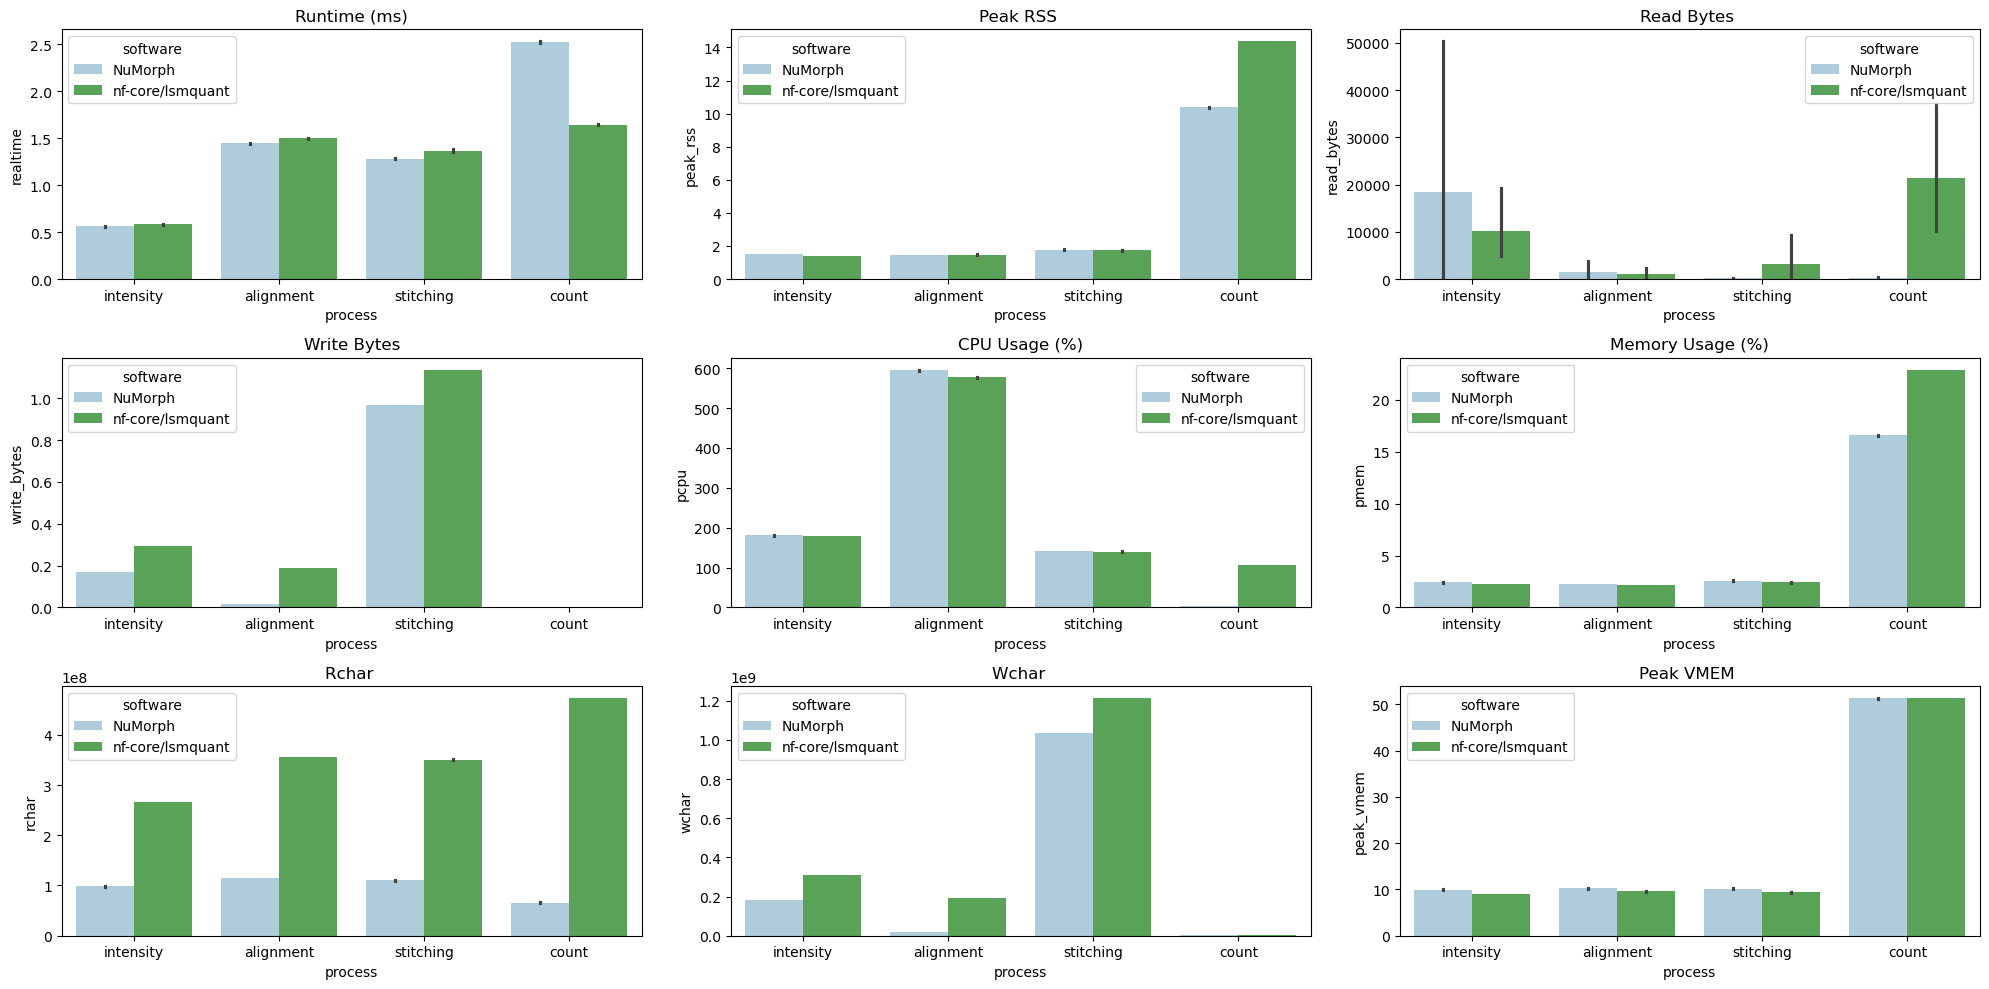

In [28]:
# barplots for all resources 
fig, axs = plt.subplots(3, 3, figsize=(20, 10))
sns.barplot(data=benchmark_df, x='process', y='realtime', hue='software', ax=axs[0, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='peak_rss', hue='software', ax=axs[0, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='read_bytes', hue='software', ax=axs[0, 2], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='write_bytes', hue='software', ax=axs[1, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='pcpu', hue='software', ax=axs[1, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='pmem', hue='software', ax=axs[1, 2], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='rchar', hue='software', ax=axs[2, 0], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='wchar', hue='software', ax=axs[2, 1], palette=palette)
sns.barplot(data=benchmark_df, x='process', y='peak_vmem', hue='software', ax=axs[2, 2], palette=palette)
axs[0, 0].set_title('Runtime (ms)')
axs[0, 1].set_title('Peak RSS ')
axs[0, 2].set_title('Read Bytes ')
axs[1, 0].set_title('Write Bytes')
axs[1, 1].set_title('CPU Usage (%)')
axs[1, 2].set_title('Memory Usage (%)')
axs[2, 0].set_title('Rchar ')
axs[2, 1].set_title('Wchar ')
axs[2, 2].set_title('Peak VMEM ')

plt.tight_layout()



/tmp/ipykernel_1302748/3766531764.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=14, rotation=0)
/tmp/ipykernel_1302748/3766531764.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=14, rotation=0)


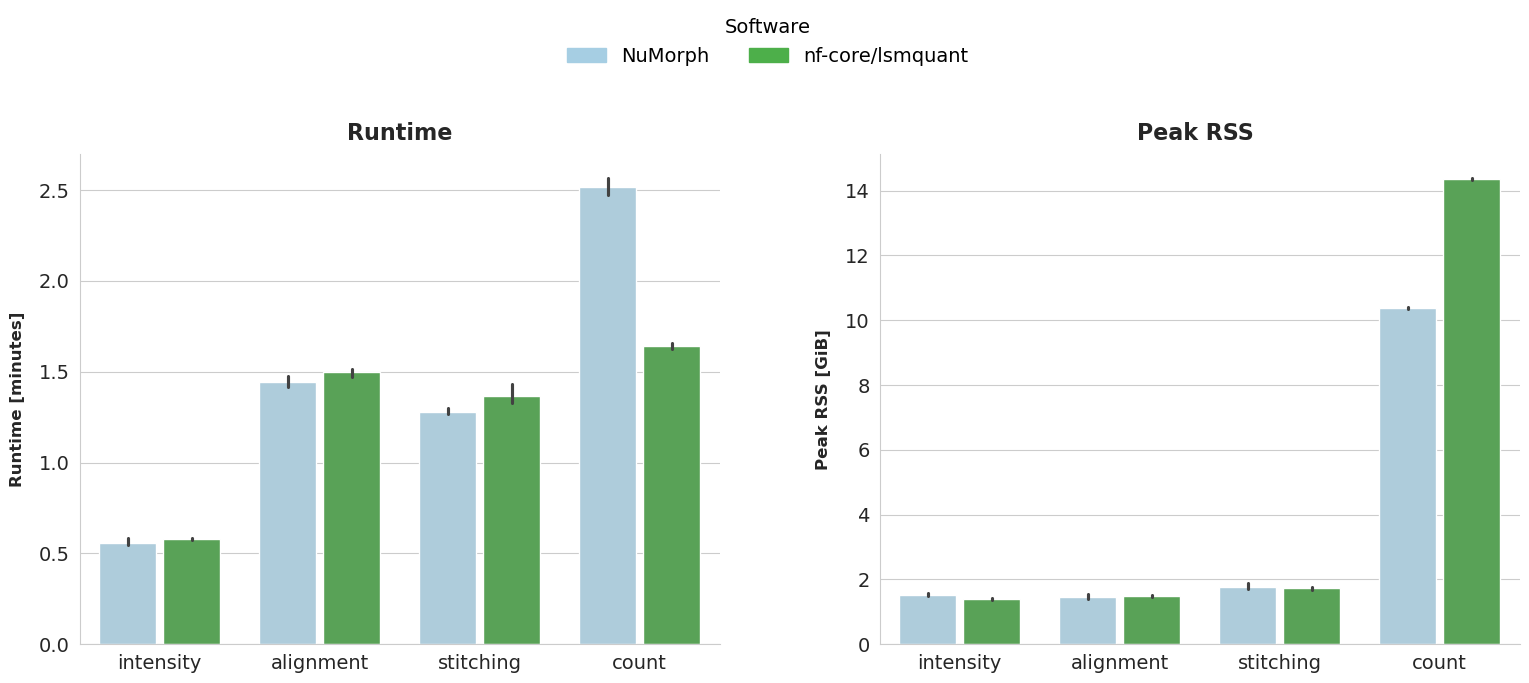

In [ ]:
processes = benchmark_df['process'].unique()
metrics = [
    ("realtime", "Runtime", "Runtime [minutes]"),
    ("peak_rss",  "Peak RSS ", "Peak RSS [GiB]"),
]
 
fig = plt.figure(figsize=(16, 7))
 
# Use the FULL figure width for the 2 bar plots side by side
# (previously gs_outer[0] only used the left half, leaving the right half empty)
gs_bar = GridSpec(
    1, 2, figure=fig,
    wspace=0.25,            # space between the two subplots
    top=0.82, bottom=0.12, left=0.07, right=0.97
)
 
with sns.axes_style("whitegrid"):
    bar_axes = [fig.add_subplot(gs_bar[0, i]) for i in range(2)]
 
    for ax, (y_col, y_label, y_units) in zip(bar_axes, metrics):
        sns.barplot(
            data=benchmark_df, x='process', y=y_col,
            hue='software', legend=False,
            palette=palette, ax=ax, gap=0.1, errorbar="pi" # show a 95% interval, ranging from the 2.5 to the 97.5 percentiles(seaborn - documentation)
        )
        ax.set_title(y_label, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel(y_units, fontsize=12, fontweight="bold", labelpad=10)
        ax.yaxis.set_tick_params(labelsize=14)
 
        # Rotate x-tick labels slightly so they don't overlap each other
        ax.set_xticklabels(processes, fontsize=14, rotation=0)
        ax.tick_params(axis='x', labelsize=14)
 
        ax.spines[["top", "right"]].set_visible(False)
 
# ── Single shared legend at the top ─────────────────────────────────────────
handles = [mpatches.Patch(color=palette[s], label=s)
           for s in benchmark_df['software'].unique()]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=14,
    title_fontsize=14,
    bbox_to_anchor=(0.5, 1.04),
    frameon=False,
)

# Save figure
plt.savefig("resource_usage_testdataset.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()


#### combined bar plot and box plot 

/tmp/ipykernel_3848200/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)
/tmp/ipykernel_3848200/2156262793.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(processes, fontsize=16)


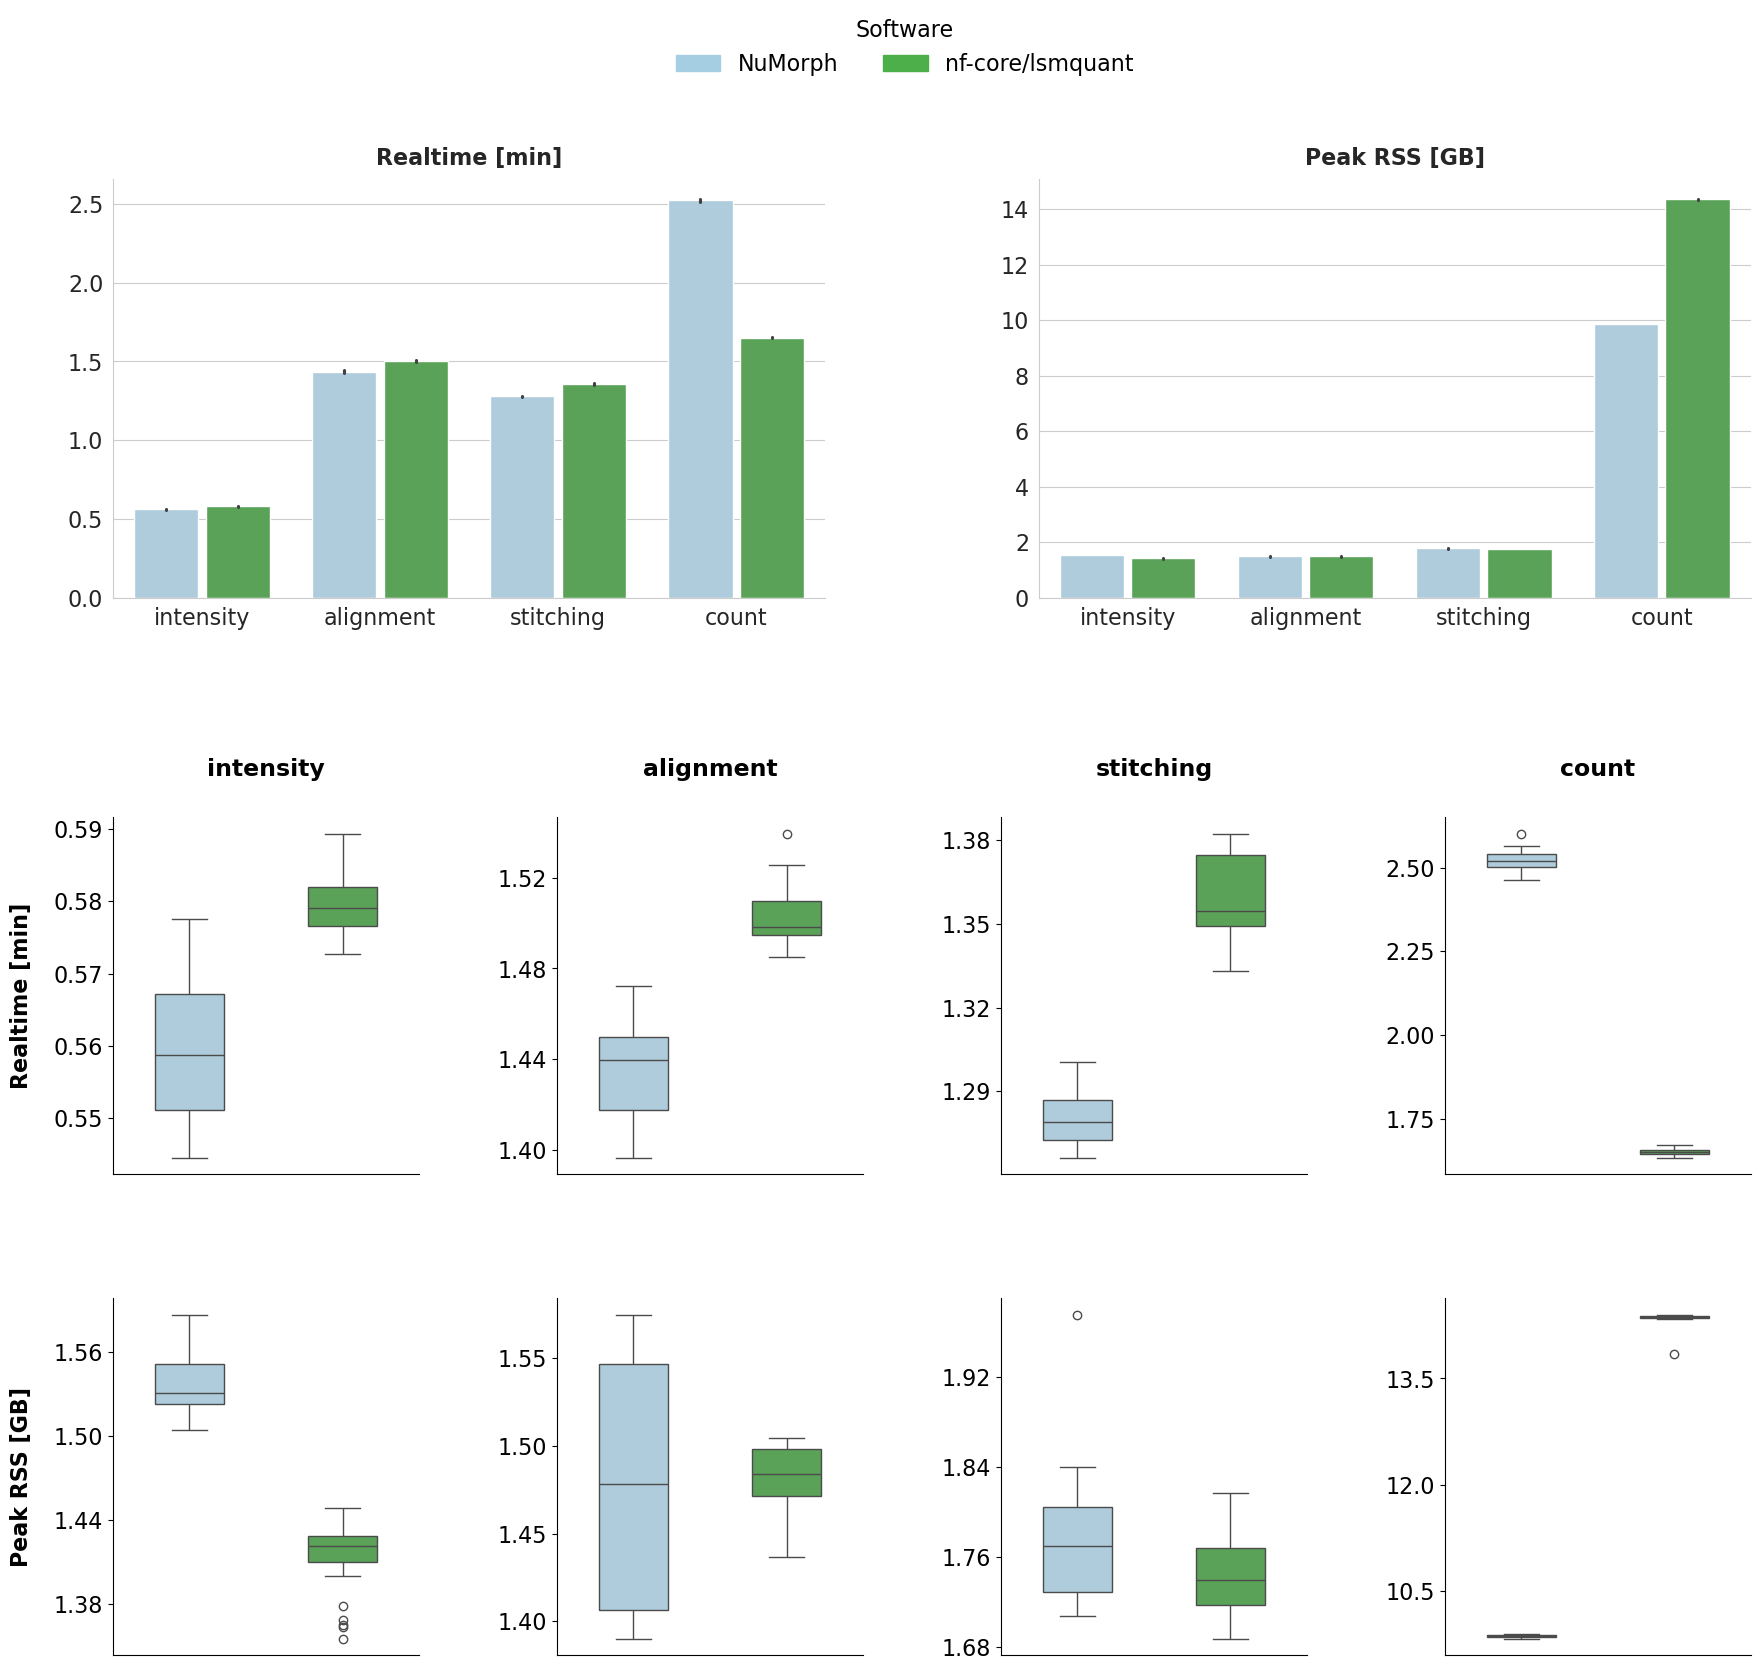

In [8]:
processes = benchmark_df['process'].unique()
metrics = [
    ("realtime", "Realtime [min]"),
    ("peak_rss",  "Peak RSS [GB]"),
]

fig = plt.figure(figsize=(18, 18))

gs_outer = GridSpec(2, 1, figure=fig, hspace=0.35,
                    top=0.88, bottom=0.06, left=0.06, right=0.97, height_ratios=[1, 2])

gs_bar   = GridSpecFromSubplotSpec(1, 2, subplot_spec=gs_outer[0], wspace=0.3)
gs_box   = GridSpecFromSubplotSpec(2, 4, subplot_spec=gs_outer[1],
                                   wspace=0.45, hspace=0.35)

# ── Row 1: 2 bar plots ──────────────────────────────────────────────────────
with sns.axes_style("whitegrid"):
    bar_axes = [fig.add_subplot(gs_bar[0, i]) for i in range(2)]

    for ax, (y_col, y_label) in zip(bar_axes, metrics):

        sns.barplot(
            data=benchmark_df, x='process', y=y_col,
            hue='software', legend=False,
            palette=palette, ax=ax, gap=0.1
        )
        ax.set_title(y_label, fontsize=16, fontweight="bold", pad=10)
        ax.set_xlabel("")
        ax.set_ylabel("")
        #ax.set_ylabel(y_label, fontsize=12, fontweight="bold", labelpad=10)
        ax.yaxis.set_tick_params(labelsize=16)
        ax.set_xticklabels(processes, fontsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Row 2 : 2×4 boxplot grid ─────────────────────────────────────────────
# Box plot axes inside gs_box

#with sns.axes_style("whitegrid"):
box_axes = [[fig.add_subplot(gs_box[row, col])
            for col in range(4)]
            for row in range(2)]

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = box_axes[row][col]
        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub, x='software', y=y_col,
            hue='software', ax=ax,
            palette=palette, legend=False,
            gap=0.1, width=0.5,
        )
        ax.yaxis.set_major_locator(plt.MaxNLocator(nbins=5))

        # Column title only on top row
        if row == 0:
            ax.set_title(process, fontsize=17, fontweight="bold", pad=30)

        # Y-axis label only on leftmost column
        ax.set_ylabel(y_label if col == 0 else "",
                    fontsize=16, fontweight="bold", labelpad=15)
        ax.set_xlabel("")
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=16)
        ax.spines[["top", "right"]].set_visible(False)

# ── Single shared legend at the top ─────────────────────────────────────────
handles = [mpatches.Patch(color=palette[s], label=s)
           for s in benchmark_df['software'].unique()]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=16,
    title_fontsize=16,
    bbox_to_anchor=(0.5, 0.98),
    frameon=False,
)

# Save figurer
plt.savefig("resource_usage_testdataset.png", dpi=300, bbox_inches="tight",
            facecolor="white")

plt.show()

#### Plot other monitored resources



In [1]:

processes = benchmark_df['process'].unique()  # ['intensity', 'alignment', 'stitching', 'count']
metrics = [
    ("read_bytes",  "Read Bytes [KB]"),
    ("write_bytes",  "Write Bytes [GB]"),
    ("pcpu",  "CPU [%]"),
    ("pmem",  "Memory [%]"),
]

fig, axes = plt.subplots(
    nrows=4, ncols=4,
    figsize=(20, 20),
    gridspec_kw={"hspace": 0.35, "wspace": 0.4}
)

for row, (y_col, y_label) in enumerate(metrics):
    for col, process in enumerate(processes):
        ax = axes[row, col]

        df_sub = benchmark_df[benchmark_df['process'] == process]

        sns.boxplot(
            data=df_sub,
            x='software',
            y=y_col,
            hue='software',
            ax=ax,
            palette=palette,
            legend=False,
            gap=0.1,
            width=0.5,
        )

        # Title only on top row
        if row == 0:
            ax.set_title(process, fontsize=13, fontweight="bold", pad=8)

        # Y-axis label only on leftmost column
        if col == 0:
            ax.set_ylabel(y_label, fontsize=12, fontweight="bold")
        else:
            ax.set_ylabel("")

        ax.set_xlabel("")
        ax.set_xticks([])  # remove x tick labels — legend handles software identity

        ax.tick_params(axis='y', labelsize=10)
        ax.spines[["top", "right"]].set_visible(False)

# Single shared legend — pull handles from any axis
handles = [
    plt.matplotlib.patches.Patch(color=palette[s], label=s)
    for s in benchmark_df['software'].unique()
]
fig.legend(
    handles=handles,
    title="Software",
    loc="upper center",
    ncol=len(handles),
    fontsize=11,
    title_fontsize=11,
    bbox_to_anchor=(0.5, 1.02),
    frameon=False,
)

fig.suptitle("")  # clear any auto title
plt.tight_layout()
plt.show()

NameError: name 'benchmark_df' is not defined

### Scaling results

#### Plot scaling results

runtime for Numorph were taken from the runtime_summary.txt file file converted into minutes by dividing by 6000 manually
runtime for lsmquant were take from the pipeline report manually

In [19]:
matlab_process = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [3.08, 6.12, 9.07, 12.19, 15.19, 18.32, 21.30, 24.46, 27.85, 30.71]}
nextflow_scaling_data = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [4.75, 5.67, 7.57, 8.92, 10.92, 12.15, 14.23, 15.95, 17.80, 19.70]}

In [26]:
# scaling with count process 
numorph_process_all = {'n_samples': [1,2,3,4,5,6,7,8,9,10],  'duration [minutes]': [(3.08 + 2.93) , 
                                                                                    (6.12 +2.88 + 2.85), 
                                                                                    (9.07 + 2.88 + 2.92 + 2.84), 
                                                                                    (12.19 + 2.86 + 2.86 + 2.84 + 2.85), 
                                                                                    (15.19 + 2.83 + 2.88+ 2.90+ 2.84+2.89), 
                                                                                    (18.32 + 2.81 +2.84+ 2.81+ 2.85+ 2.75+ 2.90), 
                                                                                    (21.30 + 2.93+ 2.83+ 2.91+ 2.88+ 2.84+ 2.88+ 2.85), 
                                                                                    (24.46 + 2.92+ 2.88+ 2.86+ 2.86+ 2.86+ 2.88+ 2.81 + 2.83), 
                                                                                    (27.85 + 2.88 + 2.84 + 2.89 + 2.81 + 2.89 + 2.85+ 2.85 + 2.83 + 2.81), 
                                                                                    (30.71 + 2.91+ 2.81+ 2.87+ 2.89+ 2.80 + 2.88 + 2.88+ 2.84 + 2.77 + 2.83)]}
lsmquant_process_all = {'n_samples': [1,2,3,4,5,6,7,8,9,10], 'duration [minutes]': [21.1, 39.01, 55.57, 73.53,  91.67, 108.65, 126.42, 145.87, 163.13,180.9]}

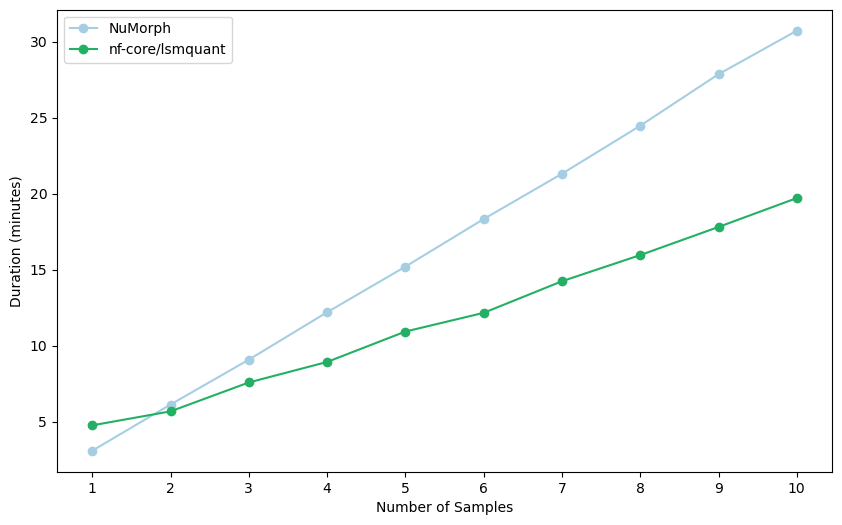

In [25]:
# plot the scaling results: x axis is n_samples and y axis is the duration in minutesfor numorph and nf-core/lsmquant
# show all x axis ticks
plt.figure(figsize=(10, 6))
plt.plot(matlab_process['n_samples'], matlab_process['duration [minutes]'], marker='o', label='NuMorph', color="#a6cee3")
plt.plot(nextflow_scaling_data['n_samples'], nextflow_scaling_data['duration [minutes]'], marker='o', label='nf-core/lsmquant', color="#24B064")
plt.xlabel('Number of Samples')
plt.xticks(matlab_process['n_samples'])  # Show all x-axis ticks
plt.ylabel('Duration (minutes)')
#plt.title('Scaling of Total Wall Time with Number of Samples')
plt.legend()
plt.savefig("scaling_preprocessing.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

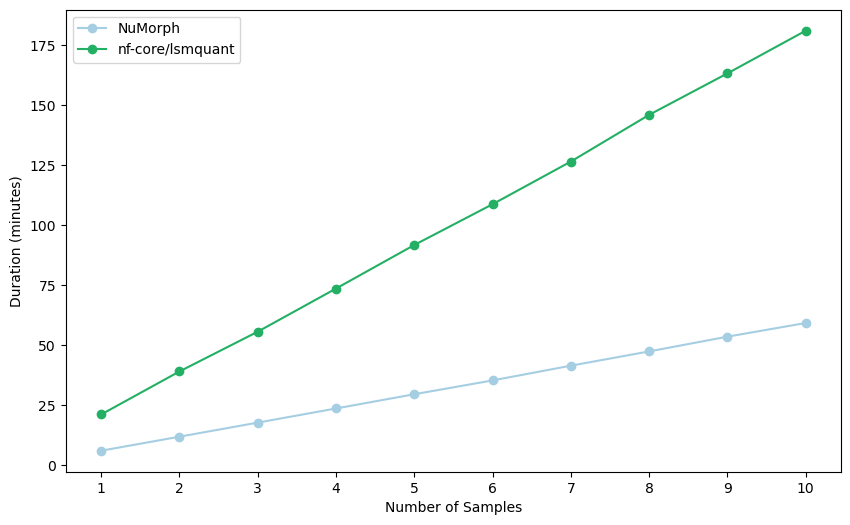

In [29]:
# plot scaling results with all processes

plt.figure(figsize=(10, 6))
plt.plot(numorph_process_all['n_samples'], numorph_process_all['duration [minutes]'], marker='o', label='NuMorph', color="#a6cee3")
plt.plot(lsmquant_process_all['n_samples'], lsmquant_process_all['duration [minutes]'], marker='o', label='nf-core/lsmquant', color="#24B064")
plt.xlabel('Number of Samples')
plt.xticks(numorph_process_all['n_samples'])  # Show all x-axis ticks
plt.ylabel('Duration (minutes)')
#plt.title('Scaling of Total Wall Time with Number of Samples')
plt.legend()
plt.savefig("scaling_all_processes.png", dpi=300, bbox_inches="tight",
            facecolor="white")
plt.show()

#### plot FAIRsoft score


In [23]:
FAIR_score = pd.DataFrame({
    'software': ['NuMorph', 'nf-core/lsmquant'],
    'Findability': [66, 100],
    'Accessability': [85, 85],
    'Interoperability': [82.7, 87.7],
    'Reusability': [70, 100]
})

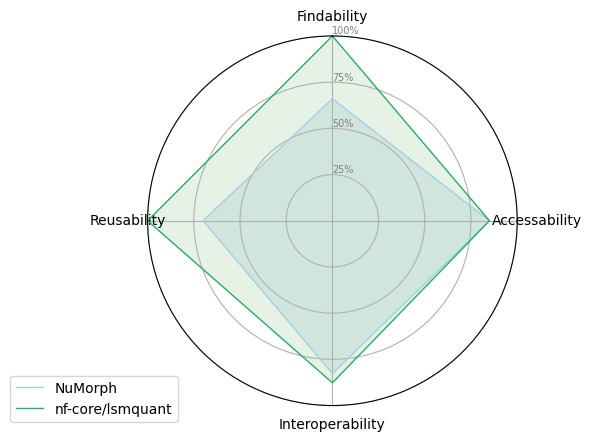

In [24]:
# ------- PART 1: Create background
 
# number of variable
categories=list(FAIR_score)[1:]
N = len(categories)
 
# What will be the angle of each axis in the plot? (we divide the plot / number of variable)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]
 
# Initialise the spider plot
ax = plt.subplot(111, polar=True)
 
# If you want the first axis to be on top:
ax.set_theta_offset(pi / 2)
ax.set_theta_direction(-1)
 
# Draw one axe per variable + add labels
plt.xticks(angles[:-1], categories)
 
# Draw ylabels
ax.set_rlabel_position(0)
plt.yticks([25,50,75,100], ["25%","50%","75%", "100%"], color="grey", size=7)
plt.ylim(0,100)
 

# ------- PART 2: Add plots
 
# Plot each individual = each line of the data
# I don't make a loop, because plotting more than 3 groups makes the chart unreadable
 
# Ind1
values=FAIR_score.loc[0].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="NuMorph", color="#a6cee3")
ax.fill(angles, values, 'o', alpha=0.1)
 
# Ind2
values=FAIR_score.loc[1].drop('software').values.flatten().tolist()
values += values[:1]
ax.plot(angles, values, linewidth=1, linestyle='solid', label="nf-core/lsmquant", color="#24B064")
ax.fill(angles, values, 'g', alpha=0.1)
 
# Add legend
plt.legend(loc='upper right', bbox_to_anchor=(0.1, 0.1))

# Show the graph
plt.show()